In [ ]:
import os
os.chdir(r'D:\支付宝一年')  # Windows

原始列名： ['交易号                  ', '商家订单号               ', '交易创建时间              ', '付款时间                ', '最近修改时间              ', '交易来源地     ', '类型              ', '交易对方            ', '商品名称                ', '金额（元）   ', '收/支     ', '交易状态    ', '服务费（元）   ', '成功退款（元）  ', '备注                  ', '资金状态     ', 'Unnamed: 16']
共 17 列，120 行

前3行：
            交易号                    \
0  2026090123001473671423193864\t   
1  2026090122001473671418640320\t   
2  2026082623001473671452725646\t   

                                商家订单号                 交易创建时间                \
0                 2963421788249633EON0140675896309\t  2026-09-01 16:00:34    
1  5212660000482200002026090111011323016623271784...  2026-09-01 08:06:46    
2                 0001N202608260000000017232547618\t  2026-08-26 18:24:02    

   付款时间                  最近修改时间                     交易来源地       \
0  2026-09-01 16:00:34   2026-09-01 16:00:34   其他（包括阿里巴巴和外部商家）   
1  2026-09-01 08:06:46   2026-09-01 08:06:46   其他（包括阿里巴巴和外部商家）   
2

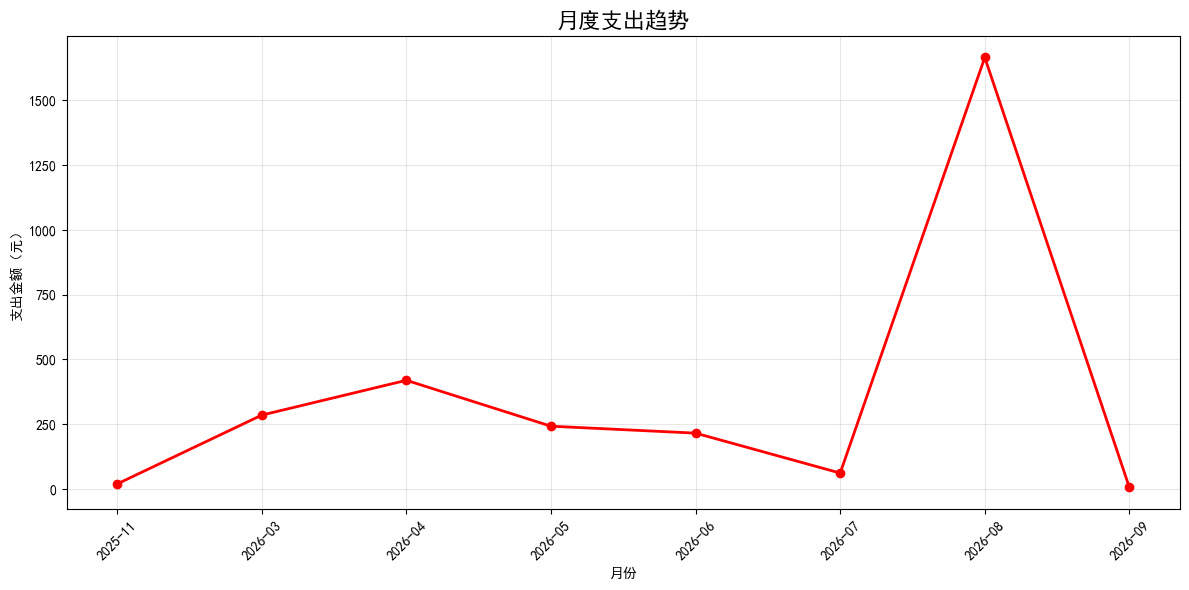


📊 支出最高的月份：2026-08，共支出 1665.86 元


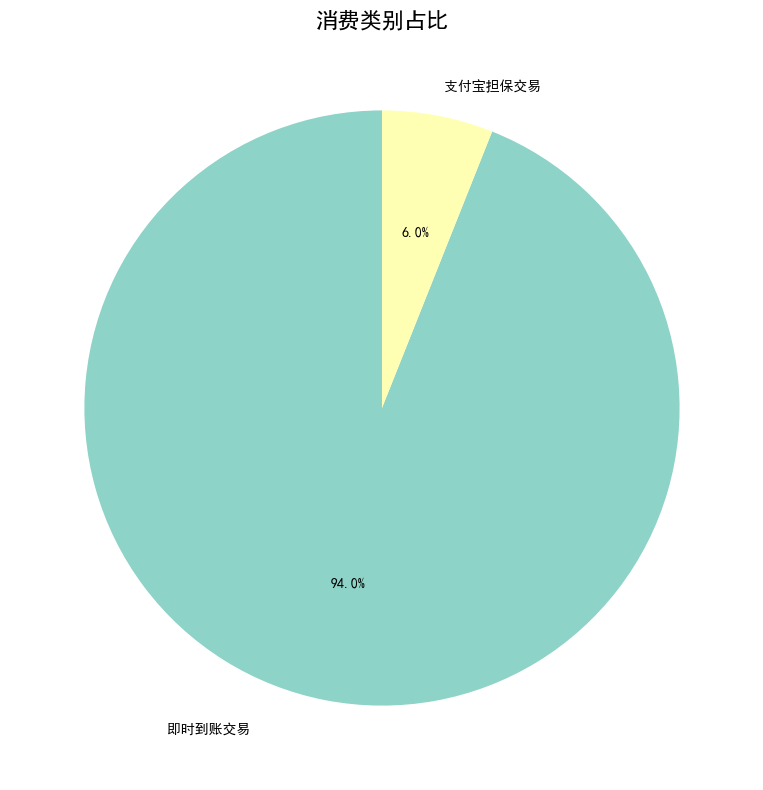


📊 最大支出类别：即时到账交易          ，占比 94.0%


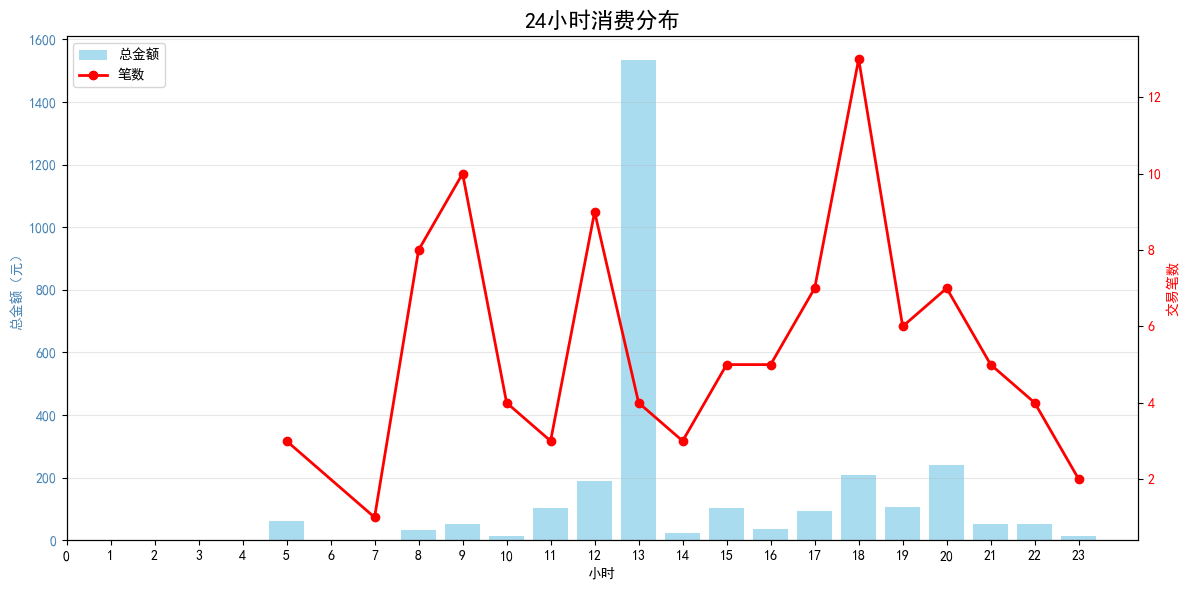


📊 消费高峰时段：13:00，共消费 1533.46 元


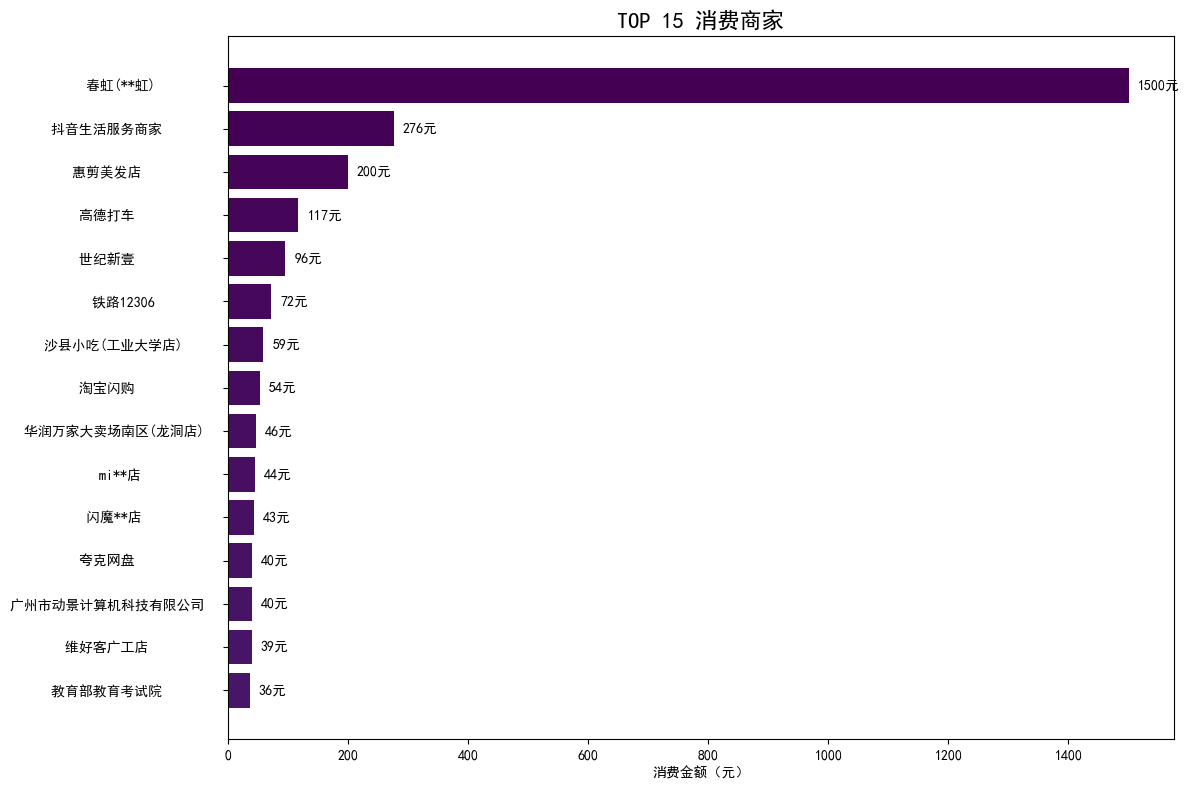


📊 TOP 5 消费商家：
交易对方            
春虹(**虹)             1500.00
抖音生活服务商家             276.49
惠剪美发店                200.00
高德打车                 117.46
世纪新壹                  95.56
Name: 金额_清洗, dtype: float64


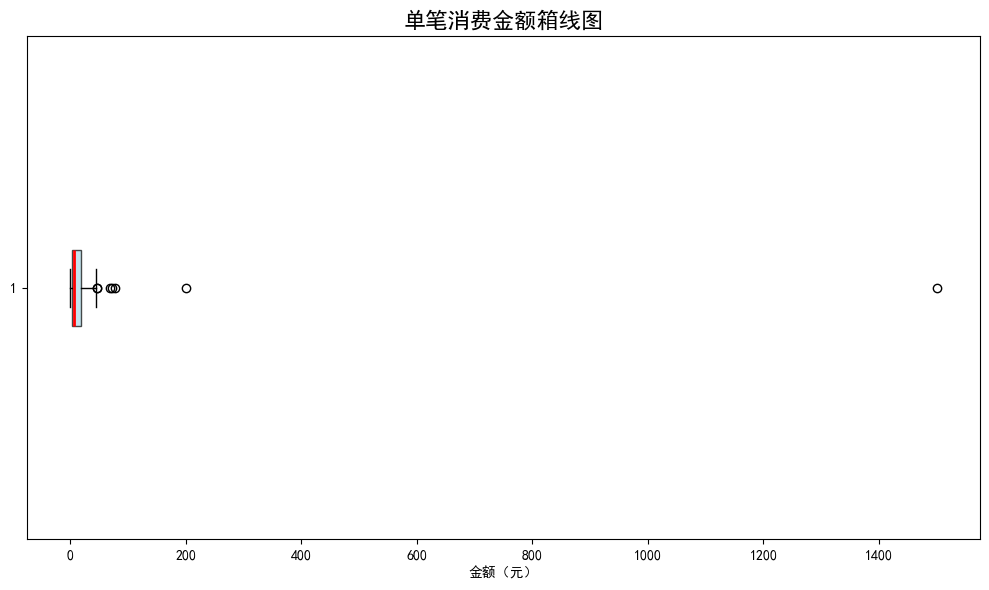


📊 异常值阈值：44.99 元
共发现 7 笔异常消费，占总交易 7.1%

TOP 10 异常消费：
                  时间_清洗  类型                交易对方              \
10  2026-08-01 13:41:48  即时到账交易            春虹(**虹)            
64  2026-04-25 20:38:55  即时到账交易            惠剪美发店              
2   2026-08-26 18:24:02  即时到账交易            高德打车               
106 2026-03-30 12:27:13  即时到账交易            铁路12306            
103 2026-03-31 11:46:48  即时到账交易            抖音生活服务商家           
105 2026-03-30 15:57:21  即时到账交易            华润万家大卖场南区(龙洞店)     
22  2026-06-18 17:56:16  即时到账交易            抖音生活服务商家           

                       商品名称                    金额_清洗  
10                     转账                    1500.00  
64                     收钱码收款                  200.00  
2                      高德打车订单                  78.21  
106                    火车票                     72.00  
103  仅亏一波王炸福利售完即止鲜切牛肉+海鲜+鲜货烧烤甜品单人自助全天无限畅...    69.00  
105                    商品                      46.40  
22                  100纯牛肉世界波鸡牛大满足双人餐可外送毕业季    45.80  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==================== 第0步：基础设置 ====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# ==================== 第1步：读取CSV ====================
file_name = 'alipay_record_20260903_2012_1.csv'  
try:
    df = pd.read_csv(file_name, skiprows=4, encoding='gbk')
except:
    df = pd.read_csv(file_name, skiprows=4, encoding='utf-8')

print("原始列名：", df.columns.tolist())
print(f"共 {len(df.columns)} 列，{len(df)} 行")
print("\n前3行：")
print(df.head(3))

# ==================== 第2步：自动识别关键列 ====================
def find_col(df, keywords):
    """根据关键词自动匹配列名"""
    for col in df.columns:
        col_str = str(col).lower().replace('（', '(').replace('）', ')')
        for kw in keywords:
            if kw.lower() in col_str:
                return col
    return None

# 自动找列
amount_col = find_col(df, ['金额', 'money'])           # 金额列
time_col   = find_col(df, ['创建时间', '时间', 'time']) # 时间列
type_col   = find_col(df, ['类型', '分类', 'category'])  # 消费类型列
merchant_col = find_col(df, ['交易对方', '对方'])  # 去掉"商家"，避免匹配到"商家订单号"
status_col = find_col(df, ['状态', 'status'])           # 交易状态列
inout_col  = find_col(df, ['收/支', '收支', '收入', '支出']) # 收支列
name_col   = find_col(df, ['商品', '名称', 'name'])     # 商品名称列

print(f"\n✅ 自动识别结果：")
print(f"  金额列: {amount_col}")
print(f"  时间列: {time_col}")
print(f"  类型列: {type_col}")
print(f"  商家列: {merchant_col}")
print(f"  状态列: {status_col}")
print(f"  收支列: {inout_col}")
print(f"  商品列: {name_col}")

# 检查是否找到了关键列
if not all([amount_col, time_col, inout_col]):
    raise ValueError("关键列识别失败！请把上面的'原始列名'输出发给我，我帮你调整。")

# ==================== 第3步：数据清洗 ====================
# 只保留交易成功（如果有状态列）
if status_col:
    df = df[df[status_col].astype(str).str.contains('成功', na=False)].copy()

# 处理金额：去掉¥、逗号、空格，转浮点数，取绝对值
df['金额_清洗'] = df[amount_col].astype(str).str.replace('[¥,\\s]', '', regex=True)
df['金额_清洗'] = pd.to_numeric(df['金额_清洗'], errors='coerce').abs()

# 处理时间
df['时间_清洗'] = pd.to_datetime(df[time_col], errors='coerce')
df['年月'] = df['时间_清洗'].dt.to_period('M')
df['小时'] = df['时间_清洗'].dt.hour

# 只分析支出
expense = df[df[inout_col].astype(str).str.contains('支出', na=False)].copy()
expense = expense.dropna(subset=['金额_清洗', '时间_清洗'])

print(f"\n✅ 清洗完成！共 {len(expense)} 笔有效支出记录")
print(f"时间范围：{expense['时间_清洗'].min()} 至 {expense['时间_清洗'].max()}")

# ==================== 分析1：月度支出趋势 ====================
monthly = expense.groupby('年月')['金额_清洗'].sum()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly.values, marker='o', color='red', linewidth=2, markersize=6)
plt.title('月度支出趋势', fontsize=16)
plt.xlabel('月份')
plt.ylabel('支出金额（元）')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_month = monthly.idxmax()
print(f"\n📊 支出最高的月份：{max_month}，共支出 {monthly[max_month]:.2f} 元")

# ==================== 分析2：消费类别占比（饼图） ====================
if type_col:
    category = expense.groupby(type_col)['金额_清洗'].sum().sort_values(ascending=False)
    
    top_n = 8
    if len(category) > top_n:
        others = category.iloc[top_n:].sum()
        category = category.iloc[:top_n]
        category['其他'] = others
    
    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set3(range(len(category)))
    plt.pie(category, labels=category.index, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title('消费类别占比', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 最大支出类别：{category.index[0]}，占比 {category.iloc[0]/category.sum()*100:.1f}%")
else:
    print("⚠️ 未找到类型列，跳过类别分析")

# ==================== 分析3：消费时段分布 ====================
hourly = expense.groupby('小时').agg({'金额_清洗': ['sum', 'count']})
hourly.columns = ['总金额', '笔数']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(hourly.index, hourly['总金额'], color='skyblue', alpha=0.7, label='总金额')
ax1.set_xlabel('小时')
ax1.set_ylabel('总金额（元）', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['笔数'], color='red', marker='o', linewidth=2, label='笔数')
ax2.set_ylabel('交易笔数', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('24小时消费分布', fontsize=16)
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3, axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

peak_hour = hourly['总金额'].idxmax()
print(f"\n📊 消费高峰时段：{peak_hour}:00，共消费 {hourly.loc[peak_hour, '总金额']:.2f} 元")

# ==================== 分析4：TOP 15 消费商家 ====================
if merchant_col:
    merchant = expense.groupby(merchant_col)['金额_清洗'].sum().sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(range(len(merchant)))
    plt.barh(range(len(merchant)), merchant.values, color=colors)
    plt.yticks(range(len(merchant)), merchant.index)
    plt.xlabel('消费金额（元）')
    plt.title('TOP 15 消费商家', fontsize=16)
    plt.gca().invert_yaxis()
    
    for i, value in enumerate(merchant.values):
        plt.text(value + merchant.max()*0.01, i, f'{value:.0f}元', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 TOP 5 消费商家：")
    print(merchant.head(5))
else:
    print("⚠️ 未找到商家列，跳过商家分析")

# ==================== 分析5：异常消费检测 ====================
plt.figure(figsize=(10, 6))
plt.boxplot(expense['金额_清洗'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.title('单笔消费金额箱线图', fontsize=16)
plt.xlabel('金额（元）')
plt.tight_layout()
plt.show()

Q1 = expense['金额_清洗'].quantile(0.25)
Q3 = expense['金额_清洗'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = expense[expense['金额_清洗'] > upper_bound].sort_values('金额_清洗', ascending=False)

print(f"\n📊 异常值阈值：{upper_bound:.2f} 元")
print(f"共发现 {len(outliers)} 笔异常消费，占总交易 {len(outliers)/len(expense)*100:.1f}%")
print("\nTOP 10 异常消费：")
display_cols = ['时间_清洗', type_col or '类型', merchant_col or '商家', name_col or '商品', '金额_清洗']
display_cols = [c for c in display_cols if c in outliers.columns]
print(outliers[display_cols].head(10))